<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/11AugSession1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Word2Vec on sample dataset

In [101]:
# gensim : library for most of embeddings like word2vec , glove , fasttext
!pip install gensim

In [102]:
# import gensim ,word2vec
import gensim
from gensim.models import Word2Vec

In [103]:
sentences = [
    ['natural' , 'language' , 'processing' , 'is' , 'a' , 'field' , 'of' , 'ai'],
    ['word' , 'embeddings' , 'capture' , 'the', 'semantic' , 'meaning' , 'of' , 'text'],
    ['word2vec' , 'creates' , 'dense' ,'vectors' , 'for' , 'each' , 'word']
]

In [104]:
# to train using word2vec
model = Word2Vec(vector_size=100, window=3 ,sg=1 , min_count=1)

In [105]:
# train it
model.build_vocab(sentences)

In [106]:
# queries to check the results
similar_words = model.wv.most_similar('language' ,topn=3)
print(similar_words)

[('word2vec', 0.31900984048843384), ('ai', 0.16207124292850494), ('creates', 0.11074147373437881)]


In [107]:
sentences = [
    ["king" , "queen" , "royal" , "palace" , "kingdom"],
    ["king" , "man" , "prince" , "royal" , "kingdom"] ,
    ["queen" , "woman" , "princess" , "royal" , "kingdom"],
    ["man" , "woman" , "boy" , "girl"],
    ["prince" , "princess" , "king" , "queen"],
    ["apple" , "banana" , "orange" , "mango" , "fruit"],
    ["banana" , "apple" , "mango" , "fruit"],
    ["car" , "bus" ,"train" , "vehicle" , "transport"],
    ["car" , "bus" , "road" , "vehicle"]
]


In [108]:
model = Word2Vec(vector_size=100 , window=5 , sg=1 , min_count=1)

In [109]:
print("Vocabulary size" ,len(model.wv))
print("vector size=" , model.wv.vector_size)

Vocabulary size 0
vector size= 100


In [110]:
model.build_vocab(sentences)
model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)

vector = model.wv['king']
print(vector)

[-8.2426779e-03  9.2993546e-03 -1.9766092e-04 -1.9672764e-03
  4.6036304e-03 -4.0953159e-03  2.7431143e-03  6.9399667e-03
  6.0654259e-03 -7.5107943e-03  9.3823504e-03  4.6718083e-03
  3.9661205e-03 -6.2435055e-03  8.4599797e-03 -2.1501649e-03
  8.8251876e-03 -5.3620026e-03 -8.1294188e-03  6.8245591e-03
  1.6711927e-03 -2.1985089e-03  9.5136007e-03  9.4938548e-03
 -9.7740470e-03  2.5052286e-03  6.1566923e-03  3.8724565e-03
  2.0227872e-03  4.3050171e-04  6.7363144e-04 -3.8206363e-03
 -7.1402504e-03 -2.0888723e-03  3.9238976e-03  8.8186832e-03
  9.2591504e-03 -5.9759365e-03 -9.4026709e-03  9.7643770e-03
  3.4297847e-03  5.1661171e-03  6.2823449e-03 -2.8042626e-03
  7.3227035e-03  2.8302716e-03  2.8710044e-03 -2.3803699e-03
 -3.1282497e-03 -2.3701417e-03  4.2764368e-03  7.6057913e-05
 -9.5842788e-03 -9.6655441e-03 -6.1481940e-03 -1.2856961e-04
  1.9974159e-03  9.4319675e-03  5.5843508e-03 -4.2906962e-03
  2.7831673e-04  4.9643586e-03  7.6983096e-03 -1.1442233e-03
  4.3234206e-03 -5.81437

In [111]:
similar_words = model.wv.most_similar('queen' ,topn=3)
print(similar_words)

[('mango', 0.1990705132484436), ('princess', 0.17272749543190002), ('vehicle', 0.1707448661327362)]


In [112]:
pairs = [('king'  , 'queen') , ("car" , "bus") , ("apple" ,"mango")]
for pair in pairs:
  print(pair ,model.wv.similarity(pair[0] ,pair[1]))

('king', 'queen') -0.013523611
('car', 'bus') 0.019331275
('apple', 'mango') 0.026806807


In [113]:
print(model.wv.similarity("king" , "queen"))

-0.013523611


In [114]:
# find out the top 5 similar words for "queen"
# check similarity between bus and vehicle
# retrain the model with window size 5 and check all the results again
# above questions help to understand how windowsize can impact results

similar_words = model.wv.most_similar("queen" ,topn=5)
print(similar_words)

[('mango', 0.1990705132484436), ('princess', 0.17272749543190002), ('vehicle', 0.1707448661327362), ('orange', 0.15288551151752472), ('boy', 0.14861318469047546)]


In [115]:
# check similarity between bus and vehicle
print(model.wv.similarity("bus" , "vehicle"))

0.13894282


In [116]:
# retrain the model with window size 5 and check all the results again



In [117]:
# analogy
# give th pair of words along with a negative to check relationship
model.wv.most_similar(positive=["king" , "woman"] , negative=["man"] ,topn=1)
# [man , queen] [woman]
# fruit , car [vehicle]
# girl prince -> boy



[('queen', 0.13966691493988037)]

In [118]:
# visualize the word vectors in 2d using PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [119]:
words = list(model.wv.index_to_key)
print(words)
vectors = model.wv[words]

['kingdom', 'royal', 'queen', 'king', 'vehicle', 'bus', 'car', 'fruit', 'mango', 'banana', 'apple', 'princess', 'woman', 'prince', 'man', 'road', 'transport', 'train', 'orange', 'girl', 'boy', 'palace']


In [120]:
# now apply pca onto vectors
pca  = PCA(n_components = 2, random_state=0)
vectors_2d= pca.fit_transform(vectors)

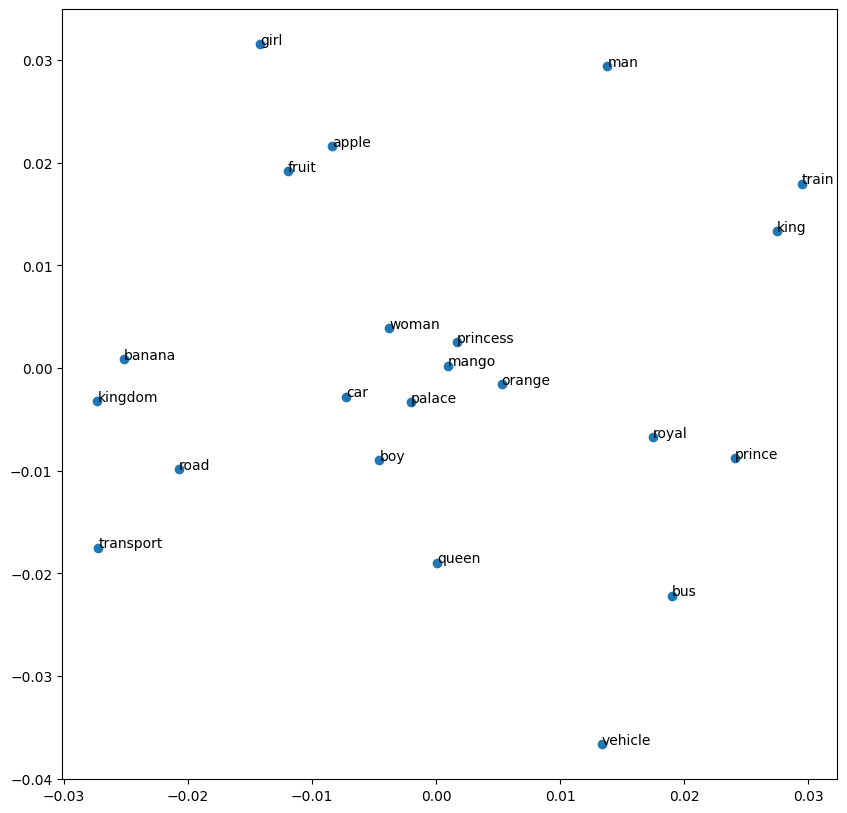

In [121]:
# now do the plot
plt.figure(figsize=(10,10))
plt.scatter(vectors_2d[:,0] , vectors_2d[:,1])
for i, word in enumerate(words):
  plt.annotate(word , (vectors_2d[i,0] , vectors_2d[i,1]))
plt.show()

In [125]:
# build Cbow and skipgram model and compare their results on similarity with respect to king
model_sg = Word2Vec(sentences , vector_size=100, window=3 , sg=1 ,min_count=1)
model_cb = Word2Vec(sentences , vector_size=100, window=3 , sg=0 ,min_count=1)

# now both results
similar_words =model_sg.wv.most_similar("queen" , topn=3)
print(similar_words)
similar_words = model_cb.wv.most_similar("queen" , topn=3)
print(similar_words)

[('mango', 0.1991206258535385), ('princess', 0.17275631427764893), ('vehicle', 0.17043547332286835)]
[('mango', 0.1991206258535385), ('princess', 0.17274188995361328), ('vehicle', 0.17024874687194824)]


In [127]:
# popular dataset
# wikipedia with 400k vocab , dimension 50d to 300d  (text data )
# common crawl : 1.9M ,300 (web scraping data )
# twitter dataset : 27B tokens ,1.2M vocab , 250 , 200d (social media dataset)



In [132]:
# download wiki dataset
import gensim.downloader as api
glv = api.load('glove-wiki-gigaword-50')
# glv100 = api.load('glove-wiki-gigaword-100')

In [140]:
# check the vocabulary size
print("vocabulary size: " , len(glv.key_to_index))
print("vector Size: " , glv.vector_size)
# check for specific word exists in the vocabulary

print("Bangalore in vocab: " , "Bangalore" in glv.key_to_index)
print("Cranes in vocab:" , "cranes" in glv.key_to_index)

vocabulary size:  400000
vector Size:  50
Bangalore in vocab:  False
Cranes in vocab: True


In [141]:
# check most similar words for 'bangalore'
similar_words = glv.most_similar("apple" , topn=3)
print(similar_words)

[('blackberry', 0.7543067336082458), ('chips', 0.7438644170761108), ('iphone', 0.7429664134979248)]


In [147]:
similar_words = glv.most_similar("cricket" , topn=3)
print(similar_words)

[('indies', 0.8089948296546936), ('twenty20', 0.8088222146034241), ('rugby', 0.8044811487197876)]
